/var/folders/7y/tb8vlfv937523rgqdlf0zjy40000gn/T/ipykernel_35965/3603863547.py:18: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not hasattr(np, 'bool8'):


PHASE 1: Pre-training base model with 2 actions
Episode 10/300, Reward: -121.61, Eps: 0.050
Episode 20/300, Reward: -190.12, Eps: 0.050
Episode 30/300, Reward: -297.64, Eps: 0.050
Episode 40/300, Reward: -104.37, Eps: 0.050
Episode 50/300, Reward: -74.53, Eps: 0.050
Episode 60/300, Reward: -161.19, Eps: 0.050
Episode 70/300, Reward: 28.35, Eps: 0.050
Episode 80/300, Reward: -140.09, Eps: 0.050
Episode 90/300, Reward: -189.81, Eps: 0.050
Episode 100/300, Reward: -1.69, Eps: 0.050
Episode 110/300, Reward: -146.04, Eps: 0.050
Episode 120/300, Reward: -110.81, Eps: 0.050
Episode 130/300, Reward: -124.68, Eps: 0.050
Episode 140/300, Reward: -188.62, Eps: 0.050
Episode 150/300, Reward: -196.37, Eps: 0.050
Episode 160/300, Reward: -66.94, Eps: 0.050
Episode 170/300, Reward: -116.13, Eps: 0.050
Episode 180/300, Reward: -122.46, Eps: 0.050
Episode 190/300, Reward: 46.78, Eps: 0.050
Episode 200/300, Reward: -117.42, Eps: 0.050
Episode 210/300, Reward: -76.15, Eps: 0.050
Episode 220/300, Reward: 

/var/folders/7y/tb8vlfv937523rgqdlf0zjy40000gn/T/ipykernel_35965/3603863547.py:478: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  base_dict = torch.load("base_model.pth", ma

Episode 10/300, Reward: -259.83, Eps: 0.192
Episode 20/300, Reward: -128.19, Eps: 0.050
Episode 30/300, Reward: -284.40, Eps: 0.050
Episode 40/300, Reward: -126.92, Eps: 0.050
Episode 50/300, Reward: -20.37, Eps: 0.050
Episode 60/300, Reward: -367.43, Eps: 0.050
Episode 70/300, Reward: -461.27, Eps: 0.050
Episode 80/300, Reward: -189.93, Eps: 0.050
Episode 90/300, Reward: -17.99, Eps: 0.050
Episode 100/300, Reward: 206.69, Eps: 0.050
Episode 110/300, Reward: -187.25, Eps: 0.050
Episode 120/300, Reward: 154.81, Eps: 0.050
Episode 130/300, Reward: 280.28, Eps: 0.050
Episode 140/300, Reward: 270.48, Eps: 0.050
Episode 150/300, Reward: 265.44, Eps: 0.050
Episode 160/300, Reward: -403.75, Eps: 0.050
Episode 170/300, Reward: 202.09, Eps: 0.050
Episode 180/300, Reward: 25.57, Eps: 0.050
Episode 190/300, Reward: 265.79, Eps: 0.050
Episode 200/300, Reward: 223.72, Eps: 0.050
Episode 210/300, Reward: -216.58, Eps: 0.050
Episode 220/300, Reward: 8.50, Eps: 0.050
Episode 230/300, Reward: -289.35, 

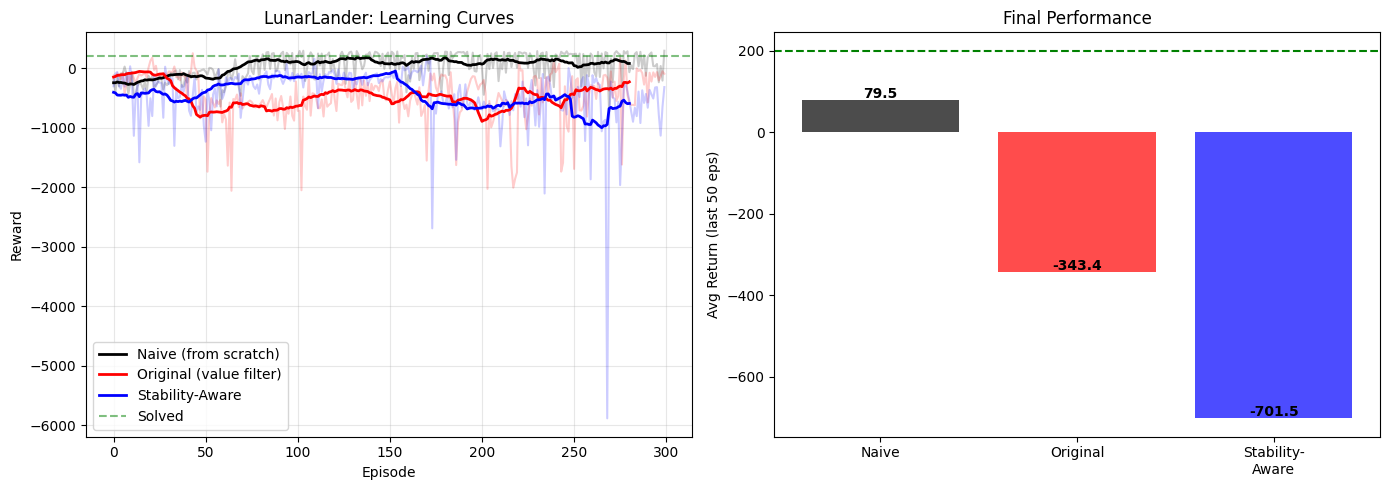


SUMMARY
Naive:           Final avg = 79.54
Original:        Final avg = -343.39, Reuse=11895, Reject=14222
Stability-Aware: Final avg = -701.52, Reuse=13771, Reject(V/S/C)=11631/8572/87


In [3]:
"""
Lunar Lander: Stability-Aware Filtering Comparison
===================================================

Compares three methods:
1. Naive: Train from scratch with all 4 actions (black line)
2. Original: Value improvement filter only - your method (red line)  
3. Stability-Aware: Value + density + confidence filters (blue line)

Run this script to generate comparison plots.
"""

import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import gymnasium as gym

if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from scipy.spatial import KDTree

# =============================================================================
# State Density Estimator
# =============================================================================

class StateDensityEstimator:
    def __init__(self, state_dim, k_neighbors=10, distance_threshold=0.5, 
                 buffer_size=10000, rebuild_frequency=100):
        self.k_neighbors = k_neighbors
        self.distance_threshold = distance_threshold
        self.state_buffer = deque(maxlen=buffer_size)
        self.kd_tree = None
        self.updates_since_rebuild = 0
        self.rebuild_frequency = rebuild_frequency
        self.total_queries = 0
        self.stable_queries = 0
    
    def add_state(self, state):
        self.state_buffer.append(np.array(state).flatten())
        self.updates_since_rebuild += 1
        if self.updates_since_rebuild >= self.rebuild_frequency:
            if len(self.state_buffer) >= self.k_neighbors:
                self.kd_tree = KDTree(np.array(self.state_buffer))
            self.updates_since_rebuild = 0
    
    def is_stable(self, state):
        self.total_queries += 1
        if self.kd_tree is None or len(self.state_buffer) < self.k_neighbors:
            return False, 0.0
        distances, _ = self.kd_tree.query(np.array(state).flatten(), k=self.k_neighbors)
        avg_distance = np.mean(distances)
        is_stable = avg_distance < self.distance_threshold
        if is_stable:
            self.stable_queries += 1
        return is_stable, np.exp(-avg_distance / self.distance_threshold)
    
    def get_statistics(self):
        return {'stability_rate': self.stable_queries / max(1, self.total_queries)}

# =============================================================================
# Neural Networks
# =============================================================================

class DQNNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, action_size)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)

class TransitionModel(nn.Module):
    def __init__(self, state_dim, hidden_dim=128, buffer_size=20000):
        super().__init__()
        self.fc1 = nn.Linear(state_dim + 1, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_mean = nn.Linear(hidden_dim, state_dim)
        self.fc_var = nn.Linear(hidden_dim, state_dim)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.to(self.device)
        self.optimizer = optim.Adam(self.parameters(), lr=0.001)
        self.buffer = deque(maxlen=buffer_size)
        self.min_buffer_size = 100
        
    def forward(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        return self.fc_mean(h), self.fc_var(h)
    
    def add_experience(self, state, next_state, action, actions_list):
        action_norm = (action - min(actions_list)) / (max(actions_list) - min(actions_list) + 1e-8)
        self.buffer.append((state.flatten(), np.array([action_norm]), next_state.flatten()))
    
    def can_predict(self):
        return len(self.buffer) >= self.min_buffer_size
    
    def train_model(self, batch_size=128, epochs=5):
        if not self.can_predict():
            return
        samples = list(self.buffer)[-min(len(self.buffer), 5000):]
        states = torch.FloatTensor(np.array([s[0] for s in samples])).to(self.device)
        actions = torch.FloatTensor(np.array([s[1] for s in samples])).to(self.device)
        next_states = torch.FloatTensor(np.array([s[2] for s in samples])).to(self.device)
        self.train()
        for _ in range(epochs):
            idx = torch.randperm(len(states))
            for i in range(0, len(states), batch_size):
                b = idx[i:i+batch_size]
                mean, log_var = self(torch.cat([states[b], actions[b]], dim=1))
                loss = 0.5 * (torch.exp(-log_var) * (next_states[b] - mean)**2 + log_var).mean()
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
    
    def predict(self, state, action, actions_list):
        self.eval()
        with torch.no_grad():
            action_norm = (action - min(actions_list)) / (max(actions_list) - min(actions_list) + 1e-8)
            inp = torch.FloatTensor(np.concatenate([state.flatten(), [action_norm]])).unsqueeze(0).to(self.device)
            mean, log_var = self(inp)
            confidence = np.exp(-np.mean(torch.exp(log_var).cpu().numpy()))
            return mean.cpu().numpy(), confidence

# =============================================================================
# DQN Agent (Base class for Naive training)
# =============================================================================

class DQNAgent:
    def __init__(self, state_size, action_list):
        self.state_size = state_size
        self.action_list = action_list
        self.memory = deque(maxlen=20000)
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.995
        self.batch_size = 128
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = DQNNetwork(state_size, len(action_list)).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        self.criterion = nn.MSELoss()
        self.density_estimator = StateDensityEstimator(state_size)

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return self.action_list[np.random.randint(len(self.action_list))], np.random.randint(len(self.action_list))
        with torch.no_grad():
            q = self.model(torch.FloatTensor(state).to(self.device))
        idx = torch.argmax(q[0]).item()
        return self.action_list[idx], idx

    def replay(self):
        if len(self.memory) < 500:
            return
        mb = np.random.choice(len(self.memory), self.batch_size, replace=False)
        s = torch.FloatTensor(np.array([self.memory[i][0].flatten() for i in mb])).to(self.device)
        a = torch.LongTensor([self.memory[i][1] for i in mb]).to(self.device)
        r = torch.FloatTensor([self.memory[i][2] for i in mb]).to(self.device)
        ns = torch.FloatTensor(np.array([self.memory[i][3].flatten() for i in mb])).to(self.device)
        d = torch.FloatTensor([self.memory[i][4] for i in mb]).to(self.device)
        
        with torch.no_grad():
            max_next_q = torch.max(self.model(ns), dim=1)[0]
        targets = r + self.gamma * max_next_q * (1 - d)
        current_q = self.model(s).gather(1, a.unsqueeze(1)).squeeze(1)
        loss = self.criterion(current_q, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def train(self, env, episodes=200):
        returns = []
        for ep in range(episodes):
            state, _ = env.reset()
            state = state.reshape(1, -1)
            total_reward = 0
            done = False
            while not done:
                action, action_idx = self.act(state)
                next_state, reward, term, trunc, _ = env.step(action)
                done = term or trunc
                next_state = next_state.reshape(1, -1)
                self.density_estimator.add_state(next_state)
                self.memory.append((state, action_idx, reward, next_state, done))
                self.replay()
                state = next_state
                total_reward += reward
            returns.append(total_reward)
            if (ep + 1) % 10 == 0:
                print(f"Episode {ep+1}/{episodes}, Reward: {total_reward:.2f}, Eps: {self.epsilon:.3f}")
        env.close()
        return returns

    def save(self, name):
        torch.save(self.model.state_dict(), name)

# =============================================================================
# Original Agent (Value filter only)
# =============================================================================

class OriginalAgent:
    def __init__(self, state_size, action_size, model=None):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=20000)
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.batch_size = 128
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device) if model else DQNNetwork(state_size, action_size).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        self.criterion = nn.MSELoss()
        self.transition_model = TransitionModel(state_size)
        self.reuse = 0
        self.reject = 0

    def act(self, state, actions):
        if np.random.rand() <= self.epsilon:
            return np.random.choice(actions)
        with torch.no_grad():
            q = self.model(torch.FloatTensor(state).to(self.device))
        return max([(a, q[0, a].item()) for a in actions], key=lambda x: x[1])[0]

    def replay(self):
        if len(self.memory) < 500:
            return
        mb = np.random.choice(len(self.memory), self.batch_size, replace=False)
        s = torch.FloatTensor(np.array([self.memory[i][0].flatten() for i in mb])).to(self.device)
        a = torch.LongTensor([self.memory[i][1] for i in mb]).to(self.device)
        r = torch.FloatTensor([self.memory[i][2] for i in mb]).to(self.device)
        ns = torch.FloatTensor(np.array([self.memory[i][3].flatten() for i in mb])).to(self.device)
        d = torch.FloatTensor([self.memory[i][4] for i in mb]).to(self.device)
        with torch.no_grad():
            max_next_q = torch.max(self.model(ns), dim=1)[0]
        targets = r + self.gamma * max_next_q * (1 - d)
        current_q = self.model(s).gather(1, a.unsqueeze(1)).squeeze(1)
        loss = self.criterion(current_q, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def train(self, env, base_actions, expand_actions, episodes=200):
        returns = []
        all_actions = base_actions + expand_actions
        steps = 0
        for ep in range(episodes):
            state, _ = env.reset()
            state = state.reshape(1, -1)
            total_reward = 0
            done = False
            while not done:
                # Epsilon-greedy with encouragement for new actions early on
                if ep < 30 and np.random.rand() < 0.3:
                    action = np.random.choice(expand_actions)
                elif np.random.rand() < self.epsilon:
                    action = np.random.choice(all_actions)
                else:
                    action = self.act(state, all_actions)
                
                # Value improvement filter for new actions
                if action in expand_actions and self.transition_model.can_predict():
                    pred, _ = self.transition_model.predict(state, action, expand_actions)
                    with torch.no_grad():
                        q_pred = self.model(torch.FloatTensor(pred).to(self.device))
                        q_curr = self.model(torch.FloatTensor(state).to(self.device))
                    if torch.max(q_pred).item() > torch.max(q_curr).item():
                        self.reuse += 1
                    else:
                        self.reject += 1
                        action = self.act(state, all_actions)
                
                next_state, reward, term, trunc, _ = env.step(action)
                done = term or trunc
                next_state = next_state.reshape(1, -1)
                
                if action in expand_actions:
                    self.transition_model.add_experience(state, next_state, action, expand_actions)
                
                self.memory.append((state, action, reward, next_state, done))
                self.replay()
                
                steps += 1
                if steps % 100 == 0 and self.transition_model.can_predict():
                    self.transition_model.train_model()
                
                state = next_state
                total_reward += reward
            
            returns.append(total_reward)
            if (ep + 1) % 10 == 0:
                print(f"Episode {ep+1}/{episodes}, Reward: {total_reward:.2f}, Reuse: {self.reuse}, Reject: {self.reject}")
        env.close()
        return returns

# =============================================================================
# Stability-Aware Agent
# =============================================================================

class StabilityAwareAgent:
    def __init__(self, state_size, action_size, model=None, stability_threshold=0.5, confidence_threshold=0.3):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=20000)
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.batch_size = 128
        self.stability_threshold = stability_threshold
        self.confidence_threshold = confidence_threshold
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device) if model else DQNNetwork(state_size, action_size).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        self.criterion = nn.MSELoss()
        self.transition_model = TransitionModel(state_size)
        self.density_estimator = StateDensityEstimator(state_size, distance_threshold=stability_threshold)
        self.reuse = 0
        self.reject_value = 0
        self.reject_stability = 0
        self.reject_confidence = 0

    def act(self, state, actions):
        if np.random.rand() <= self.epsilon:
            return np.random.choice(actions)
        with torch.no_grad():
            q = self.model(torch.FloatTensor(state).to(self.device))
        return max([(a, q[0, a].item()) for a in actions], key=lambda x: x[1])[0]

    def replay(self):
        if len(self.memory) < 500:
            return
        mb = np.random.choice(len(self.memory), self.batch_size, replace=False)
        s = torch.FloatTensor(np.array([self.memory[i][0].flatten() for i in mb])).to(self.device)
        a = torch.LongTensor([self.memory[i][1] for i in mb]).to(self.device)
        r = torch.FloatTensor([self.memory[i][2] for i in mb]).to(self.device)
        ns = torch.FloatTensor(np.array([self.memory[i][3].flatten() for i in mb])).to(self.device)
        d = torch.FloatTensor([self.memory[i][4] for i in mb]).to(self.device)
        with torch.no_grad():
            max_next_q = torch.max(self.model(ns), dim=1)[0]
        targets = r + self.gamma * max_next_q * (1 - d)
        current_q = self.model(s).gather(1, a.unsqueeze(1)).squeeze(1)
        loss = self.criterion(current_q, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def train(self, env, base_actions, expand_actions, episodes=200):
        returns = []
        all_actions = base_actions + expand_actions
        steps = 0
        for ep in range(episodes):
            state, _ = env.reset()
            state = state.reshape(1, -1)
            total_reward = 0
            done = False
            while not done:
                if ep < 30 and np.random.rand() < 0.3:
                    action = np.random.choice(expand_actions)
                elif np.random.rand() < self.epsilon:
                    action = np.random.choice(all_actions)
                else:
                    action = self.act(state, all_actions)
                
                # Stability-aware filter for new actions
                if action in expand_actions and self.transition_model.can_predict():
                    pred, confidence = self.transition_model.predict(state, action, expand_actions)
                    
                    # Check 1: Value improvement
                    is_stable, _ = self.density_estimator.is_stable(pred)
                    if is_stable:
                        with torch.no_grad():
                            q_pred = self.model(torch.FloatTensor(pred).to(self.device))
                            q_curr = self.model(torch.FloatTensor(state).to(self.device))
                        
                        if torch.max(q_pred).item() <= torch.max(q_curr).item():
                            self.reject_value += 1
                            action = self.act(state, all_actions)
                        else:
                            # Check 3: Model confidence
                            if confidence < self.confidence_threshold:
                                self.reject_confidence += 1
                                action = self.act(state, all_actions)
                            else:
                                self.reuse += 1
                    else:
                        self.reject_stability += 1
                        action = self.act(state, all_actions)
                next_state, reward, term, trunc, _ = env.step(action)
                done = term or trunc
                next_state = next_state.reshape(1, -1)
                
                self.density_estimator.add_state(next_state)
                
                if action in expand_actions:
                    self.transition_model.add_experience(state, next_state, action, expand_actions)
                
                self.memory.append((state, action, reward, next_state, done))
                self.replay()
                
                steps += 1
                if steps % 100 == 0 and self.transition_model.can_predict():
                    self.transition_model.train_model()
                
                state = next_state
                total_reward += reward
            
            returns.append(total_reward)
            if (ep + 1) % 10 == 0:
                print(f"Episode {ep+1}/{episodes}, Reward: {total_reward:.2f}, "
                      f"Reuse: {self.reuse}, Reject(V/S/C): {self.reject_value}/{self.reject_stability}/{self.reject_confidence}")
        env.close()
        return returns

# =============================================================================
# Helper Functions
# =============================================================================

def expand_model_weights(base_dict, base_actions, expand_actions, full_actions, state_size, device):
    model = DQNNetwork(state_size, len(full_actions)).to(device)
    filtered = {k: v for k, v in base_dict.items() if not k.startswith("fc4.")}
    model.load_state_dict(filtered, strict=False)
    
    base_w, base_b = base_dict["fc4.weight"].to(device), base_dict["fc4.bias"].to(device)
    new_w, new_b = model.fc4.weight.detach().clone(), model.fc4.bias.detach().clone()
    
    base_idx = {a: i for i, a in enumerate(base_actions)}
    for a in base_actions:
        new_w[a], new_b[a] = base_w[base_idx[a]], base_b[base_idx[a]]
    for a in expand_actions:
        src = np.random.choice(base_actions)
        new_w[a], new_b[a] = base_w[base_idx[src]], base_b[base_idx[src]]
    
    with torch.no_grad():
        model.fc4.weight.copy_(new_w)
        model.fc4.bias.copy_(new_b)
    return model

def moving_average(data, window=20):
    return np.convolve(data, np.ones(window)/window, mode='valid')

# =============================================================================
# Main Experiment
# =============================================================================

if __name__ == "__main__":
    BASE_ACTIONS = [0, 2]      # Nothing, Main engine
    EXPAND_ACTIONS = [1, 3]    # Left, Right engine  
    FULL_ACTIONS = [0, 1, 2, 3]
    EPISODES = 300
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    env = gym.make("LunarLander-v3")
    state_size = env.observation_space.shape[0]
    
    print("="*60)
    print("PHASE 1: Pre-training base model with 2 actions")
    print("="*60)
    base_agent = DQNAgent(state_size, BASE_ACTIONS)
    base_returns = base_agent.train(env, episodes=EPISODES)
    base_agent.save("base_model.pth")
    
    base_dict = torch.load("base_model.pth", map_location=device)
    
    print("\n" + "="*60)
    print("PHASE 2: Comparison Experiments")
    print("="*60)
    
    # 1. Naive
    print("\n[1] NAIVE (4 actions from scratch)...")
    env1 = gym.make("LunarLander-v3")
    naive = DQNAgent(state_size, FULL_ACTIONS)
    naive_returns = naive.train(env1, episodes=EPISODES)
    
    # 2. Original
    print("\n[2] ORIGINAL (value filter only)...")
    env2 = gym.make("LunarLander-v3")
    model2 = expand_model_weights(base_dict, BASE_ACTIONS, EXPAND_ACTIONS, FULL_ACTIONS, state_size, device)
    original = OriginalAgent(state_size, len(FULL_ACTIONS), model2)
    original_returns = original.train(env2, BASE_ACTIONS, EXPAND_ACTIONS, episodes=EPISODES)
    
    # 3. Stability-Aware
    print("\n[3] STABILITY-AWARE...")
    env3 = gym.make("LunarLander-v3")
    model3 = expand_model_weights(base_dict, BASE_ACTIONS, EXPAND_ACTIONS, FULL_ACTIONS, state_size, device)
    stability = StabilityAwareAgent(state_size, len(FULL_ACTIONS), model3)
    stability_returns = stability.train(env3, BASE_ACTIONS, EXPAND_ACTIONS, episodes=EPISODES)
    
    # Plot
    print("\n" + "="*60)
    print("Generating plots...")
    print("="*60)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1 = axes[0]
    ax1.plot(naive_returns, alpha=0.2, color='black')
    ax1.plot(original_returns, alpha=0.2, color='red')
    ax1.plot(stability_returns, alpha=0.2, color='blue')
    ax1.plot(moving_average(naive_returns), color='black', lw=2, label='Naive (from scratch)')
    ax1.plot(moving_average(original_returns), color='red', lw=2, label='Original (value filter)')
    ax1.plot(moving_average(stability_returns), color='blue', lw=2, label='Stability-Aware')
    ax1.axhline(200, color='green', ls='--', alpha=0.5, label='Solved')
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Reward')
    ax1.set_title('LunarLander: Learning Curves')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    ax2 = axes[1]
    methods = ['Naive', 'Original', 'Stability-\nAware']
    finals = [np.mean(naive_returns[-50:]), np.mean(original_returns[-50:]), np.mean(stability_returns[-50:])]
    bars = ax2.bar(methods, finals, color=['black', 'red', 'blue'], alpha=0.7)
    ax2.axhline(200, color='green', ls='--', label='Solved')
    ax2.set_ylabel('Avg Return (last 50 eps)')
    ax2.set_title('Final Performance')
    for bar, val in zip(bars, finals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:.1f}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('lunarlander_3way_comparison.png', dpi=150)
    plt.show()
    
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"Naive:           Final avg = {np.mean(naive_returns[-50:]):.2f}")
    print(f"Original:        Final avg = {np.mean(original_returns[-50:]):.2f}, Reuse={original.reuse}, Reject={original.reject}")
    print(f"Stability-Aware: Final avg = {np.mean(stability_returns[-50:]):.2f}, "
          f"Reuse={stability.reuse}, Reject(V/S/C)={stability.reject_value}/{stability.reject_stability}/{stability.reject_confidence}")
